# Pneumonia Detection from Chest X-Rays

## Project Overview

Pneumonia is a serious respiratory infection that causes significant morbidity and mortality worldwide, particularly in children and the elderly. Timely and accurate diagnosis from chest X-rays is critical, yet it remains prone to human error under high workload conditions.

In this project, a **Convolutional Neural Network (CNN)** is built to classify chest X-ray images as either **Normal** or **Pneumonia** using the **PneumoniaMNIST** dataset from the MedMNIST collection — a standardized benchmark for medical image classification tasks.

### Dataset
**PneumoniaMNIST** is derived from the Guangzhou Women and Children's Medical Center chest X-ray dataset. It contains **5,856 grayscale images** resized to 28x28 pixels, split into predefined train, validation, and test sets across two classes: Normal and Pneumonia.

### Objectives
- Load and inspect the PneumoniaMNIST dataset
- Apply data augmentation and preprocessing for CNN training
- Build and train a CNN model with regularization
- Evaluate performance using Accuracy, AUC-ROC, and a Confusion Matrix

### Tools and Libraries
`Python` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `TensorFlow / Keras` · `MedMNIST`

In [4]:
# Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Install and import MedMNIST
os.system("pip install medmnist -q")
import medmnist
from medmnist import PneumoniaMNIST, INFO

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("TensorFlow version:", tf.__version__)
print("MedMNIST version  :", medmnist.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.20.0
MedMNIST version  : 3.0.2
All libraries loaded successfully


## Loading and Inspecting the Dataset

The PneumoniaMNIST dataset is loaded directly through the MedMNIST API, which handles the download automatically on first use. The data is extracted as NumPy arrays for straightforward handling in TensorFlow. We inspect the class names, image shapes, and class distribution across all three splits to understand what we are working with before any preprocessing.

In [5]:
# Load dataset info
info = INFO["pneumoniamnist"]
print("Description :", info["description"])
print("Classes     :", info["label"])
print("n_channels  :", info["n_channels"])

# Download and load splits as NumPy arrays
train_data = PneumoniaMNIST(split="train",      download=True)
val_data   = PneumoniaMNIST(split="val",        download=True)
test_data  = PneumoniaMNIST(split="test",       download=True)

# Extract arrays
X_train, y_train = np.array([s[0] for s in train_data]), np.array([s[1][0] for s in train_data])
X_val,   y_val   = np.array([s[0] for s in val_data]),   np.array([s[1][0] for s in val_data])
X_test,  y_test  = np.array([s[0] for s in test_data]),  np.array([s[1][0] for s in test_data])

print("\nSplit sizes:")
print(f"  Train : {X_train.shape}, labels: {y_train.shape}")
print(f"  Val   : {X_val.shape},   labels: {y_val.shape}")
print(f"  Test  : {X_test.shape},  labels: {y_test.shape}")

print("\nClass distribution:")
for split_name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    print(f"  {split_name}: Normal={counts[0]}, Pneumonia={counts[1]}")

Description : The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
Classes     : {'0': 'normal', '1': 'pneumonia'}
n_channels  : 1


100%|██████████| 4.17M/4.17M [00:01<00:00, 2.56MB/s]



Split sizes:
  Train : (4708, 28, 28), labels: (4708,)
  Val   : (524, 28, 28),   labels: (524,)
  Test  : (624, 28, 28),  labels: (624,)

Class distribution:
  Train: Normal=1214, Pneumonia=3494
  Val: Normal=135, Pneumonia=389
  Test: Normal=234, Pneumonia=390


### Observations

The dataset loaded cleanly across all three splits, giving **4,708 training images**, 524 validation images, and 624 test images. All images are 28x28 grayscale, consistent with the MedMNIST preprocessing specification.

A notable class imbalance is present across all splits. In the training set, pneumonia cases outnumber normal cases by roughly **3:1** (3,494 vs 1,214). This imbalance is clinically realistic — chest X-ray datasets tend to over-represent disease cases — but it means the model could achieve deceptively high accuracy by simply favouring the pneumonia class. This will be accounted for during training by passing class weights to the model.

## Visualizing Sample Images

Before preprocessing, we look at a sample of images from each class to get a sense of what the model will be learning from. Despite the small 28x28 resolution, the structural differences between normal and pneumonia X-rays should still be visible — pneumonia cases typically show increased opacity and haziness in the lung fields.

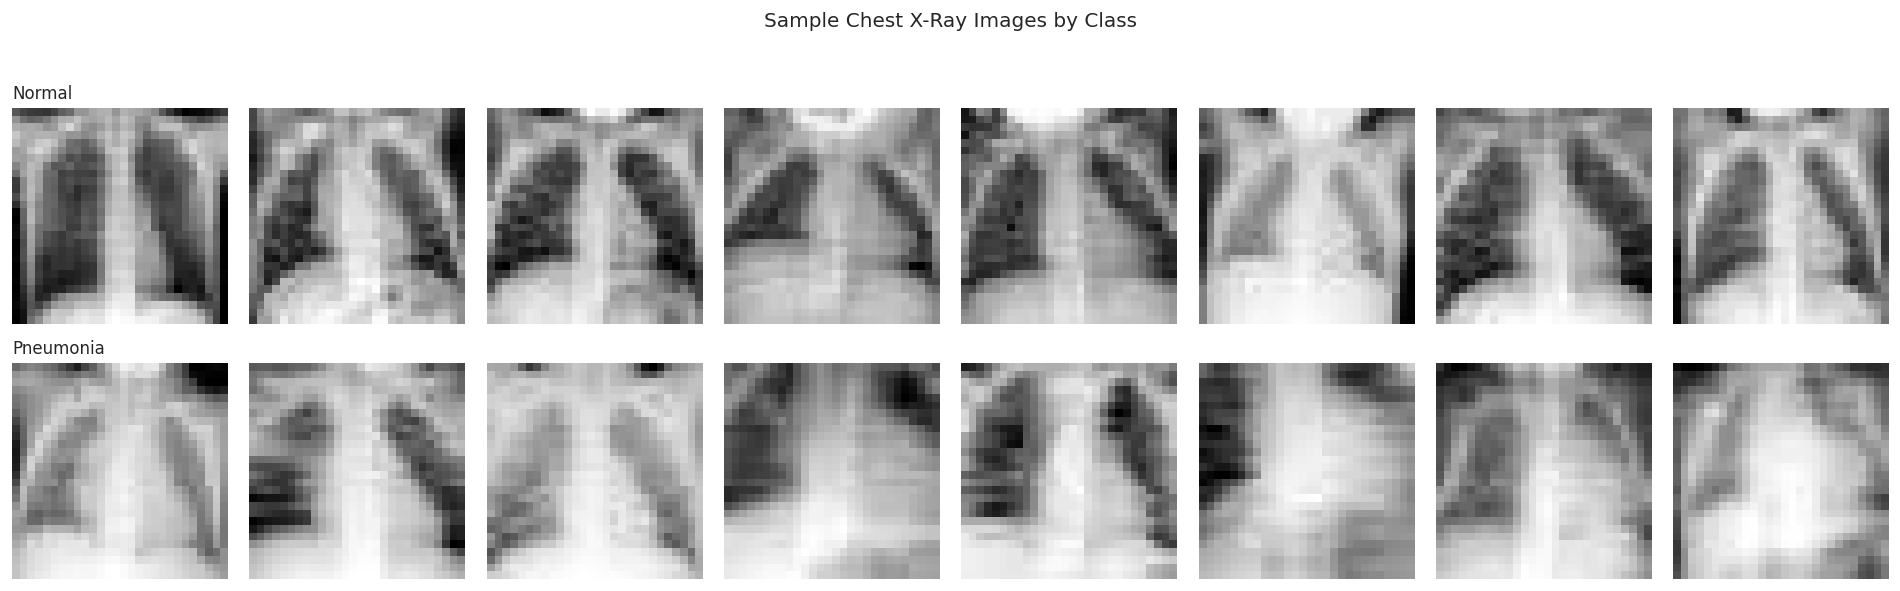

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for label, row in [(0, 0), (1, 1)]:
    class_name = "Normal" if label == 0 else "Pneumonia"
    indices = np.where(y_train == label)[0][:8]
    for col, idx in enumerate(indices):
        axes[row, col].imshow(X_train[idx], cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=10, loc="left")

plt.suptitle("Sample Chest X-Ray Images by Class", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("sample_images.png", bbox_inches="tight")
plt.show()

### Observations

Even at 28x28 resolution, meaningful visual differences between the two classes are discernible. Normal X-rays tend to show clearly defined lung fields with darker regions representing air-filled lungs and a distinct cardiac silhouette. Pneumonia X-rays show notably more diffuse whitish opacity throughout the lung fields, reflecting the fluid and inflammatory consolidation characteristic of the infection.

The variability within the pneumonia class is also evident — some cases show localized opacity while others affect broader regions — which makes this a genuinely non-trivial classification task even for a human observer at this resolution.

## Preprocessing and Preparing the Data

The raw pixel values are normalized from their original 0–255 range to 0–1 to stabilize gradient updates during training. The images are also expanded from shape `(28, 28)` to `(28, 28, 1)` to satisfy the channel dimension expected by the CNN.

To address the 3:1 class imbalance identified earlier, class weights are computed and will be passed to the model during training, penalizing misclassification of the minority class more heavily. A data augmentation pipeline is applied to the training set — random horizontal flips and small rotations — to improve generalization by exposing the model to varied orientations of the same underlying anatomy.

In [7]:
# Normalize pixel values to [0, 1]
X_train_n = X_train.astype("float32") / 255.0
X_val_n   = X_val.astype("float32")   / 255.0
X_test_n  = X_test.astype("float32")  / 255.0

# Expand channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
X_train_n = np.expand_dims(X_train_n, axis=-1)
X_val_n   = np.expand_dims(X_val_n,   axis=-1)
X_test_n  = np.expand_dims(X_test_n,  axis=-1)

print("Shape after preprocessing:")
print(f"  Train : {X_train_n.shape}")
print(f"  Val   : {X_val_n.shape}")
print(f"  Test  : {X_test_n.shape}")

# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weight_dict)

# Data augmentation pipeline for training
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="data_augmentation")

print("\nPreprocessing complete")

Shape after preprocessing:
  Train : (4708, 28, 28, 1)
  Val   : (524, 28, 28, 1)
  Test  : (624, 28, 28, 1)

Class weights: {0: np.float64(1.9390444810543657), 1: np.float64(0.6737263880938752)}

Preprocessing complete


### Results

All three splits are correctly shaped with the channel dimension added, confirming the data is ready for the CNN input layer.

The computed class weights reflect the imbalance well — normal cases are assigned a weight of **1.94** while pneumonia cases receive **0.67**. This means the model will treat each misclassified normal case as nearly twice as costly during training, effectively counterbalancing the fact that pneumonia examples dominate the training set.

## Building the Model

The model is a compact CNN built specifically for the 28x28 input size. Three convolutional blocks are stacked, each consisting of a Conv2D layer with ReLU activation, followed by batch normalization and max pooling. The convolutional base is then flattened and passed through two dense layers with dropout for regularization before the final sigmoid output neuron.

The augmentation pipeline is integrated directly as the first layer of the model so that it is applied automatically during training and bypassed during evaluation. The model is compiled with the Adam optimizer and binary cross-entropy loss.

In [8]:
def build_cnn(input_shape=(28, 28, 1)):
    model = keras.Sequential([
        # Augmentation (active only during training)
        data_augmentation,

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn()
model.build(input_shape=(None, 28, 28, 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,473 (974.50 KB)

 Trainable params: 249,025 (972.75 KB)

 Non-trainable params: 448 (1.75 KB)

### Model Summary

The network has **249,473 total parameters**, of which 249,025 are trainable. This is a reasonable size for a 28x28 image classification task — large enough to learn meaningful spatial features but not so large as to be computationally expensive in Colab.

The three max pooling layers progressively reduce the spatial dimensions from 28x28 down to 3x3 while the number of feature maps grows from 32 to 128, following the standard CNN design principle of trading spatial resolution for feature depth. By the time the output reaches the flatten layer, the 3x3x128 feature map is compressed into a 1,152-dimensional vector, which the dense layers then process down to the final binary prediction.

The 448 non-trainable parameters belong to the batch normalization layers, serving the same role as in Project 1.

## Training the Model

The model is trained for up to 50 epochs with a batch size of 32. The same callback strategy from Project 1 is used — early stopping monitoring validation loss with a patience of 10 epochs, and a learning rate scheduler that halves the rate when validation loss plateaus for 5 consecutive epochs. Class weights computed earlier are passed to the training loop to handle the class imbalance.

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_n, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_n, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Training complete")
print("Total epochs run:", len(history.history["loss"]))

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.8753 - loss: 0.3228 - val_accuracy: 0.7424 - val_loss: 2.4771 - learning_rate: 0.0010
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.9259 - loss: 0.1933 - val_accuracy: 0.7424 - val_loss: 3.3302 - learning_rate: 0.0010
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.9286 - loss: 0.1820 - val_accuracy: 0.8645 - val_loss: 0.3858 - learning_rate: 0.0010
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.9427 - loss: 0.1566 - val_accuracy: 0.8969 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.9354 - loss: 0.1677 - val_accuracy: 0.8874 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.9386 - loss: 0.1486 - val_accuracy: 0.9599 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.9441 - l

### Training Results

Training ran for 29 epochs before early stopping halted it, with the best weights restored from **epoch 19** where validation loss reached its lowest point at 0.0593 and validation accuracy peaked at 98.09%.

The first two epochs showed unusually high validation loss (2.47 and 3.33), which is typical early instability when the network weights are still being initialized into a useful range. From epoch 3 onward the validation loss dropped sharply and training proceeded more smoothly.

The learning rate was reduced twice — at epochs 11 and 24 — and a third reduction triggered at epoch 29 which coincided with early stopping. Each reduction helped the model refine its weights more carefully, with the most notable improvement coming after the first reduction, where validation loss dropped from 0.76 to 0.08 within a few epochs.

Training accuracy climbed steadily from 87% to nearly 98% by the final epochs, while validation accuracy tracked closely in the high 90s after epoch 6, suggesting the model generalized well despite the class imbalance.

## Visualizing Training History

The loss and accuracy curves are plotted across all training epochs. The dashed vertical line marks the best epoch from which weights were restored by early stopping.

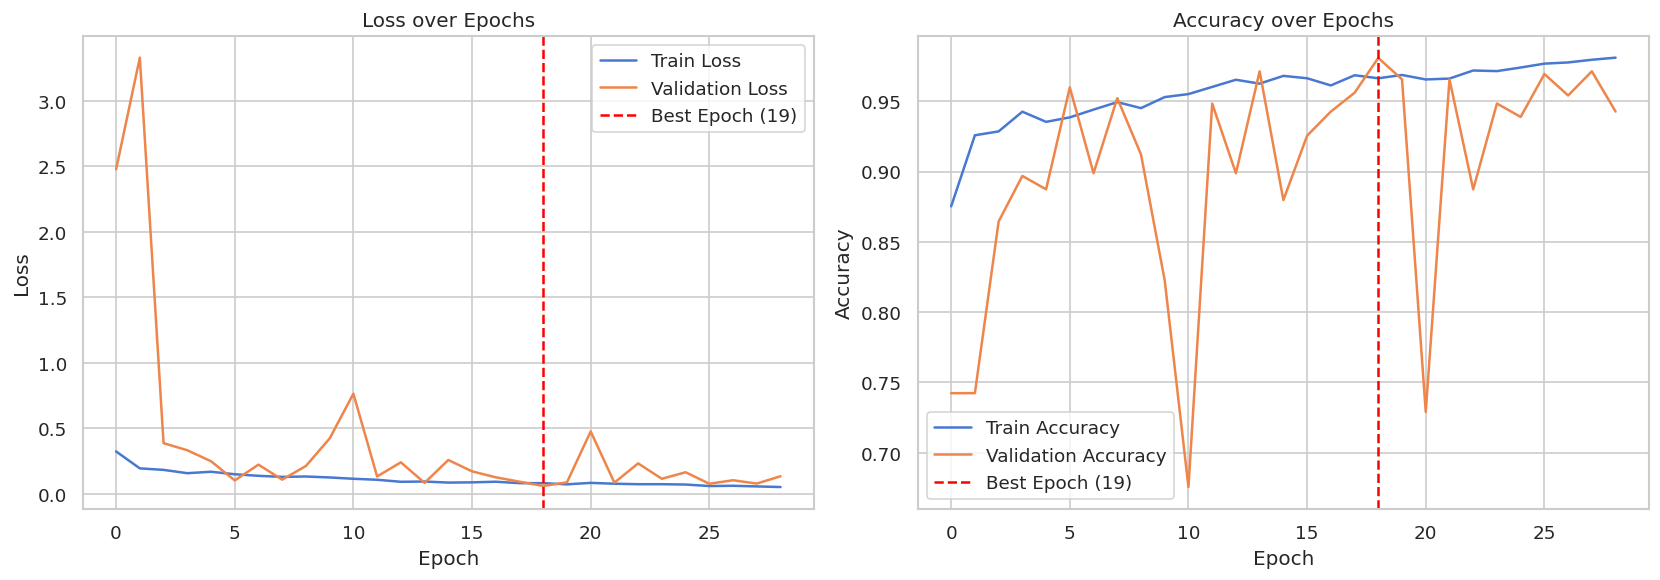

In [10]:
best_epoch = np.argmin(history.history["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch ({best_epoch + 1})")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].axvline(best_epoch, color="red", linestyle="--",
                label=f"Best Epoch ({best_epoch + 1})")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", bbox_inches="tight")
plt.show()

### Analysis

The loss plot shows the sharp early spike in validation loss at epochs 1–2 discussed earlier, followed by a rapid drop and general convergence toward low loss values for both curves. From epoch 5 onward, training loss decreases smoothly and consistently. The validation loss is noticeably noisier throughout, which is expected given that the validation set contains only 524 samples — small enough for individual batch variation to produce visible spikes.

The accuracy plot tells a similar story. Training accuracy rises steadily and stabilizes in the high 90s. Validation accuracy is volatile but trends upward, with the sharp dips corresponding directly to the validation loss spikes. Despite this volatility, the best epoch at **epoch 19** captures a point where validation accuracy reached 98.09% — the highest generalization the model achieved before the noise made further reliable improvement impossible.

The overall pattern is healthy — both curves converge at low loss values with no persistent divergence between train and validation, indicating the model learned genuine patterns from the data rather than simply memorizing the training set.

## Model Evaluation on the Test Set

The model is evaluated on the 624-sample held-out test set. As with Project 1, the evaluation covers test loss and accuracy, a full classification report, a confusion matrix, and the AUC-ROC curve. Given the class imbalance in the test set (234 normal vs 390 pneumonia), recall for the normal class is particularly important — missed pneumonia cases are costly, but so is over-predicting pneumonia in healthy patients.

Test Loss    : 0.6277
Test Accuracy: 0.8478

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.61      0.75       234
   Pneumonia       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624

AUC-ROC Score: 0.9642


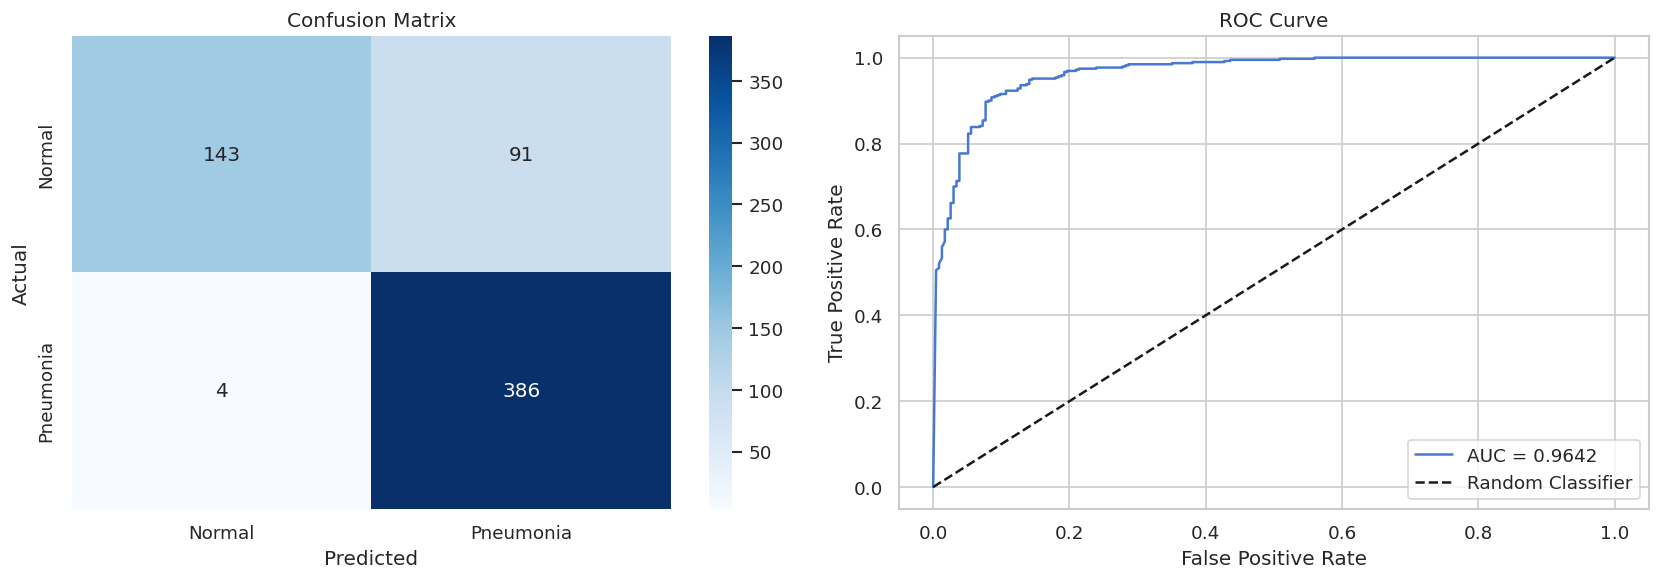

In [11]:
# Loss and accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test_n, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_n, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Normal", "Pneumonia"]))

# AUC-ROC score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation.png", bbox_inches="tight")
plt.show()

### Results

The model achieved a **test accuracy of 84.78%** and an **AUC-ROC score of 0.9642**, indicating strong overall discriminative ability between normal and pneumonia cases.

**Confusion Matrix:** Of the 390 actual pneumonia cases, 386 were correctly identified and only 4 were missed — a recall of 99%. This is the most clinically important result, as failing to detect pneumonia in a sick patient carries the greatest risk. However, of the 234 actual normal cases, only 143 were correctly classified while 91 were incorrectly flagged as pneumonia — a recall of just 61% for the normal class.

**Classification Report:** The asymmetry between the two classes is evident. The pneumonia class achieves an F1-score of 0.89 driven by near-perfect recall, while the normal class achieves an F1-score of 0.75, pulled down by the high false positive rate. This pattern is a direct consequence of the class weighting strategy — by penalizing missed pneumonia cases more heavily, the model learned to lean toward predicting pneumonia when uncertain, which is the safer clinical trade-off.

**ROC Curve:** The curve rises steeply at low false positive rates before flattening near perfect true positive rate, which is consistent with the 0.96 AUC and confirms the model ranks positive cases well across all thresholds.